# **Evaluation**

In [1]:
import json
import os
import sys

sys.path.append("../../")

from datetime import datetime, timedelta
from random import random, sample, seed

import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from metrics import (
    get_budget_efficiency,
    get_dietary_compliance,
    get_expiry_waste_score,
    get_expiry_weighted_utilisation_score,
    get_ingredient_utilisation_score,
    get_purchase_dependency_score,
    get_variety_score,
)
from openai import OpenAI
from tqdm.auto import tqdm

from engines import (
    GAMealPlanner,
    ILPMealPlanner,
    LLMMealPlanner,
    MealPlanner,
    RandomMealPlanner,
    get_pantry_ingredient,
    load_all_ingredients,
    make_preferences,
)
from models import DietaryTag, MealPlanningEnvironment, NutritionalInformation, Pantry, Recipe

load_dotenv()

True

## Evaluation Environment Setup

In [2]:
seed(1)

In [3]:
user_preferences = make_preferences()

In [4]:
all_ingredients = load_all_ingredients(filepath="../../recipe_extraction/supplemented_structured_ingredients.json")

## Scenario Construction

Five fixed test scenarios are constructed below. Each scenario is a `(pantry, preferences)` pair that is later used to build a `MealPlanningEnvironment` for every planner.

| # | Scenario | Budget | Pantry | Preferences |
|---|---|---|---|---|
| 1 | Standard | €50 | ~10 items | none |
| 2 | Low Budget | €15 | sparse | none |
| 3 | Overcrowded Pantry | €50 | 20+ items, 8+ expiring ≤3 days | none |
| 4 | Dietary Restrictions | €50 | mixed | vegan + gluten-free |
| 5 | High Nutritional Targets | €50 | balanced | 3000 kcal/day, 150 g protein |

In [5]:
CURRENT_DATE = datetime.now()

In [6]:
def build_scenario_pantry(
    ingredient_spec: dict[str, tuple[float, int]],
    all_ingredients: list,
    current_date: datetime,
) -> Pantry:
    """
    Builds a Pantry for a scenario

    :param ingredient_spec: mapping of ingredient name to (quantity_grams, days_until_expiry)
    :type ingredient_spec: dict[str, tuple[float, int]]
    :param all_ingredients: full ingredient list loaded from supplemented_structured_ingredients.json
    :type all_ingredients: list
    :param current_date: reference date used to compute expiry dates
    :type current_date: datetime

    :return: Pantry object populated with the specified ingredients
    :rtype: Pantry
    """
    pantry = Pantry()
    for name, (quantity, days) in ingredient_spec.items():
        pantry_ingredient = get_pantry_ingredient(
            name,
            current_date + timedelta(days=days),
            all_ingredients,
        )
        pantry.add(pantry_ingredient, quantity)
    return pantry

In [7]:
def filter_and_add_recipes(
    all_recipes: list[Recipe],
    pantry_ingredient_names: list[str],
    num_filtered_recipes: int,
    num_extra_recipes: int,
) -> list[Recipe]:
    """
    Filters the recipe list to those that can be made with the pantry ingredients, then adds a few random extra recipes to increase variety

    :param all_recipes: full list of recipes loaded from supplemented_structured_recipes.json
    :type all_recipes: list[Recipe]
    :param pantry_ingredient_names: list of ingredient names available in the pantry
    :type pantry_ingredient_names: list[str]
    :param num_filtered_recipes: maximum number of pantry-matching recipes to include
    :type num_filtered_recipes: int
    :param num_extra_recipes: number of random extra recipes to add for variety
    :type num_extra_recipes: int

    :return: filtered and augmented list of recipes
    :rtype: list[Recipe]
    """

    unique_ingredient_names = set(pantry_ingredient_names)

    filtered_recipe_indices = []

    for i, recipe in enumerate(all_recipes):
        if any(ingredient_name in unique_ingredient_names for ingredient_name in recipe.ingredients.keys()):
            filtered_recipe_indices.append(i)

    if len(filtered_recipe_indices) > num_filtered_recipes:
        filtered_recipe_indices = sample(filtered_recipe_indices, num_filtered_recipes)

    sampled_recipe_indices = sample(
        [i for i in range(len(all_recipes)) if i not in filtered_recipe_indices], num_extra_recipes
    )

    assert len(set(sampled_recipe_indices).intersection(set(filtered_recipe_indices))) == 0, (
        "Sampled indices should not overlap with filtered recipe indices"
    )

    return [all_recipes[i] for i in filtered_recipe_indices + sampled_recipe_indices]


### Scenario 1 (Standard)

10 pantry items, €50 budget, no dietary restrictions.

In [8]:
scenario_1_pantry_spec = {
    "chicken breast": (800, 5),
    "broccoli": (600, 4),
    "rice": (1000, 10),
    "pasta": (500, 14),
    "tomato": (400, 3),
    "onion": (300, 7),
    "garlic": (100, 14),
    "olive oil": (250, 30),
    "eggs": (360, 10),
    "carrot": (400, 6),
}

scenario_1_pantry = build_scenario_pantry(scenario_1_pantry_spec, all_ingredients, CURRENT_DATE)
scenario_1_preferences = make_preferences(weekly_budget=50.0)

print(f"Scenario 1 pantry items: {len(scenario_1_pantry.ingredients)}")

Scenario 1 pantry items: 10


### Scenario 2 (Low Budget)

Sparse pantry (4 items), €15 budget, no dietary restrictions.

In [9]:
scenario_2_pantry_spec = {
    "rice": (500, 10),
    "onion": (200, 7),
    "garlic": (100, 14),
    "tomato": (300, 4),
}

scenario_2_pantry = build_scenario_pantry(scenario_2_pantry_spec, all_ingredients, CURRENT_DATE)
scenario_2_preferences = make_preferences(weekly_budget=15.0)

print(f"Scenario 2 pantry items: {len(scenario_2_pantry.ingredients)}")

Scenario 2 pantry items: 4


### Scenario 3 (Overcrowded Pantry)

20+ pantry items, 8 of which expire within 3 days, €50 budget, no dietary restrictions.

In [10]:
scenario_3_pantry_spec = {
    # expiring very soon (<=3 days)
    "chicken breast": (600, 1),
    "broccoli": (400, 2),
    "spinach": (200, 1),
    "mushrooms": (300, 2),
    "tomato": (400, 3),
    "avocado": (250, 2),
    "Greek yogurt": (400, 3),
    "milk": (500, 1),
    # items with longer shelf life
    "rice": (1000, 10),
    "pasta": (800, 14),
    "onion": (500, 7),
    "garlic": (150, 14),
    "olive oil": (300, 30),
    "eggs": (360, 10),
    "carrot": (600, 7),
    "celery": (400, 5),
    "potato": (1000, 12),
    "sweet potato": (600, 8),
    "lentils": (500, 60),
    "chickpeas": (400, 60),
    "black beans": (400, 60),
    "oats": (600, 90),
}

scenario_3_pantry = build_scenario_pantry(scenario_3_pantry_spec, all_ingredients, CURRENT_DATE)
scenario_3_preferences = make_preferences(weekly_budget=50.0)

num_expiring_soon = sum(1 for days in scenario_3_pantry_spec.values() if days[1] <= 3)

print(f"Scenario 3 pantry items: {len(scenario_3_pantry.ingredients)} ({num_expiring_soon} expiring <=3 days)")

Scenario 3 pantry items: 22 (8 expiring <=3 days)


### Scenario 4 (Dietary Restrictions)

Mixed pantry, €50 budget, vegan + gluten-free preferences.

In [11]:
scenario_4_pantry_spec = {
    "tofu": (500, 5),
    "chickpeas": (400, 60),
    "black beans": (400, 60),
    "lentils": (500, 60),
    "spinach": (300, 3),
    "broccoli": (400, 4),
    "tomato": (400, 4),
    "garlic": (100, 14),
    "onion": (300, 7),
    "olive oil": (250, 30),
    "carrot": (400, 6),
    "corn": (300, 5),
}

scenario_4_pantry = build_scenario_pantry(scenario_4_pantry_spec, all_ingredients, CURRENT_DATE)
scenario_4_preferences = make_preferences(weekly_budget=50.0, is_vegan=True, requires_gluten_free=True)

print(f"Scenario 4 pantry items: {len(scenario_4_pantry.ingredients)}")
print(
    f"\tis_vegan={scenario_4_preferences.is_vegan}, requires_gluten_free={scenario_4_preferences.requires_gluten_free}"
)

Scenario 4 pantry items: 12
	is_vegan=True, requires_gluten_free=True


### Scenario 5 (High Nutritional Targets)

Balanced pantry, €50 budget, 3000 kcal/day and 150 g protein/day targets.

In [12]:
scenario_5_pantry_spec = {
    "chicken breast": (1200, 5),
    "salmon": (600, 3),
    "eggs": (720, 10),
    "beef": (800, 3),
    "rice": (1000, 14),
    "oats": (600, 90),
    "milk": (1000, 7),
    "broccoli": (600, 4),
    "sweet potato": (800, 8),
    "olive oil": (300, 30),
}

scenario_5_pantry = build_scenario_pantry(scenario_5_pantry_spec, all_ingredients, CURRENT_DATE)
scenario_5_preferences = make_preferences(
    weekly_budget=50.0,
    calorie_target=3000.0,
    protein_target=150.0,
)

print(f"Scenario 5 pantry items: {len(scenario_5_pantry.ingredients)}")
print(
    f"\tcalorie_target={scenario_5_preferences.calorie_target_per_day} kcal/day, protein_target={scenario_5_preferences.protein_target_per_day} g/day"
)

Scenario 5 pantry items: 10
	calorie_target=3000.0 kcal/day, protein_target=150.0 g/day


### All Scenarios

Collect all scenarios into a list for use in the evaluation runner loop.

In [13]:
NUM_FILTERED_RECIPES = 100
NUM_EXTRA_RECIPES = 50

In [14]:
with open("../../recipe_extraction/supplemented_structured_recipes.json", "r") as file:
    all_recipes = json.load(file)

In [15]:
tag_map = {
    "VEGETARIAN": DietaryTag.VEGETARIAN,
    "VEGAN": DietaryTag.VEGAN,
    "GLUTEN_FREE": DietaryTag.GLUTEN_FREE,
    "LACTOSE_FREE": DietaryTag.LACTOSE_FREE,
}

parsed_recipes = []

for unparsed_recipe in all_recipes:
    ingredients = {ingredient["ingredient"]: ingredient["quantity"] for ingredient in unparsed_recipe["ingredients"]}
    dietary_tags = [tag_map[tag] for tag in unparsed_recipe.get("dietary_tags", []) if tag in tag_map]

    recipe = Recipe(
        name=unparsed_recipe["name"],
        ingredients=ingredients,
        dietary_tags=dietary_tags,
        instructions=unparsed_recipe.get("instructions", []),
    )

    nutritional_information = unparsed_recipe["nutritional_information"]

    recipe.nutritional_information = NutritionalInformation(
        calories=nutritional_information.get("calories"),
        carbohydrates=nutritional_information.get("carbohydrates"),
        sugar=nutritional_information.get("sugar"),
        protein=nutritional_information.get("protein"),
        fat=nutritional_information.get("fat"),
        saturated_fat=nutritional_information.get("saturated_fat"),
        fiber=nutritional_information.get("fiber"),
        sodium=nutritional_information.get("sodium"),
        is_gluten_free=nutritional_information.get("is_gluten_free"),
        is_lactose_free=nutritional_information.get("is_lactose_free"),
        is_vegetarian=nutritional_information.get("is_vegetarian"),
        is_vegan=nutritional_information.get("is_vegan"),
    )

    parsed_recipes.append(recipe)

all_recipes = parsed_recipes.copy()

In [16]:
scenario_1_recipes = filter_and_add_recipes(
    all_recipes,
    [ingredient.name for ingredient in scenario_1_pantry.ingredients],
    NUM_FILTERED_RECIPES,
    NUM_EXTRA_RECIPES,
)
scenario_2_recipes = filter_and_add_recipes(
    all_recipes,
    [ingredient.name for ingredient in scenario_2_pantry.ingredients],
    NUM_FILTERED_RECIPES,
    NUM_EXTRA_RECIPES,
)
scenario_3_recipes = filter_and_add_recipes(
    all_recipes,
    [ingredient.name for ingredient in scenario_3_pantry.ingredients],
    NUM_FILTERED_RECIPES,
    NUM_EXTRA_RECIPES,
)
scenario_4_recipes = filter_and_add_recipes(
    all_recipes,
    [ingredient.name for ingredient in scenario_4_pantry.ingredients],
    NUM_FILTERED_RECIPES,
    NUM_EXTRA_RECIPES,
)
scenario_5_recipes = filter_and_add_recipes(
    all_recipes,
    [ingredient.name for ingredient in scenario_5_pantry.ingredients],
    NUM_FILTERED_RECIPES,
    NUM_EXTRA_RECIPES,
)

In [17]:
scenario_names = [
    "Scenario 1: Standard",
    "Scenario 2: Low Budget",
    "Scenario 3: Overcrowded Pantry",
    "Scenario 4: Dietary Restrictions",
    "Scenario 5: High Nutritional Targets",
]

In [18]:
all_ingredient_names = []

for recipe in [*scenario_1_recipes, *scenario_2_recipes, *scenario_3_recipes, *scenario_4_recipes, *scenario_5_recipes]:
    for ingredient_name in recipe.ingredients.keys():
        all_ingredient_names.append(ingredient_name)

In [19]:
all_ingredient_costs = {}

for ingredient_name in sorted(set(all_ingredient_names)):
    all_ingredient_costs[ingredient_name] = random()

In [20]:
scenario_environments: list[MealPlanningEnvironment] = []

for pantry, recipes, preferences in [
    (scenario_1_pantry, scenario_1_recipes, scenario_1_preferences),
    (scenario_2_pantry, scenario_2_recipes, scenario_2_preferences),
    (scenario_3_pantry, scenario_3_recipes, scenario_3_preferences),
    (scenario_4_pantry, scenario_4_recipes, scenario_4_preferences),
    (scenario_5_pantry, scenario_5_recipes, scenario_5_preferences),
]:
    environment = MealPlanningEnvironment(
        pantry=pantry,
        recipes=recipes,
        preferences=preferences,
        ingredient_costs=all_ingredient_costs,
    )

    scenario_environments.append(environment)

In [21]:
planner_metrics: dict[tuple[str, int], dict[str, float]] = {}
computation_times: dict[tuple[str, int], float] = {}

In [22]:
def evaluate_planner(
    scenario_index: int, meal_planner: MealPlanner, generation_params: dict[str, any] | None = None
) -> None:
    """
    Evaluates a meal planner by generating a meal plan and computing various metrics on it, while also measuring the computation time

    :param scenario_index: the index of the scenario to evaluate
    :type scenario_index: int
    :param meal_planner: the meal planner to evaluate
    :type meal_planner: MealPlanner
    :param generation_params: the parameters to pass to the meal if needs be
    :type generation_params: dict[str, any]
    """

    environment = meal_planner.meal_planning_environment

    computation_start_time = datetime.now()

    if generation_params is None:
        generation_params = {}

    best_meal_plan, _ = meal_planner.generate_meal_plan(**generation_params)

    computation_end_time = datetime.now()

    best_meal_plan_recipes = [
        [environment.recipes[int(index)] for index in best_meal_plan[i : i + 3]]
        for i in range(0, len(best_meal_plan), 3)
    ]

    ingredient_utilisation_score = get_ingredient_utilisation_score(
        meal_plan=best_meal_plan_recipes, pantry=environment.pantry
    )

    expiry_weighted_utilisation_score = get_expiry_weighted_utilisation_score(
        meal_plan=best_meal_plan_recipes, pantry=environment.pantry, current_date=CURRENT_DATE
    )

    expiry_waste_score = get_expiry_waste_score(
        meal_plan=best_meal_plan_recipes, pantry=environment.pantry, current_date=CURRENT_DATE
    )

    dietary_compliance = get_dietary_compliance(
        meal_plan=best_meal_plan_recipes, user_preferences=environment.preferences
    )

    budget_efficiency = get_budget_efficiency(
        meal_plan=best_meal_plan_recipes,
        pantry=environment.pantry,
        ingredient_costs=environment.ingredient_costs,
        weekly_budget=environment.preferences.weekly_budget,
    )

    purchase_dependency_score = get_purchase_dependency_score(
        meal_plan=best_meal_plan_recipes,
        pantry=environment.pantry,
    )

    variety_score = get_variety_score(meal_plan=best_meal_plan_recipes)

    planner_metrics[(meal_planner.__class__.__name__, scenario_index)] = {
        "ingredient_utilisation_score": ingredient_utilisation_score,
        "expiry_weighted_utilisation_score": expiry_weighted_utilisation_score,
        "expiry_waste_score": expiry_waste_score,
        "dietary_compliance": dietary_compliance,
        "budget_efficiency": budget_efficiency,
        "purchase_dependency_score": purchase_dependency_score,
        "variety_score": variety_score,
    }

    computation_times[(meal_planner.__class__.__name__, scenario_index)] = (
        computation_end_time - computation_start_time
    ).total_seconds()

## Evaluation

### *Random Meal Planner*

In [23]:
RANDOM_MEAL_PLANNER_SEED = 1

### *GA Meal Planner*

In [24]:
with open("../best_ga_meal_planner_hyperparameters.json", "r") as file:
    best_params = eval(file.read())

In [25]:
print(best_params)

{'population_size': 160, 'num_parents_mating': 46, 'parent_selection_type': 'sss', 'K_tournament': 10, 'keep_elitism': 1, 'crossover_type': 'uniform', 'crossover_probability': 0.6, 'mutation_type': 'scramble', 'mutation_probability': 0.02}


### *ILP Meal Planner*

In [26]:
ILP_MEAL_PLANNER_TIME_LIMIT_SECONDS = 600

### *LLM Meal Planner*

In [27]:
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

### *Evaluating all Planners*

In [28]:
all_planner_params = [
    {},
    {**best_params, "generation_print_interval": None},
    {"time_limit": ILP_MEAL_PLANNER_TIME_LIMIT_SECONDS},
    {},
]

In [29]:
total_steps = len(scenario_environments) * len(all_planner_params)

with tqdm(total=total_steps) as pbar:
    for scenario_index, scenario_environment in enumerate(scenario_environments, start=1):
        random_meal_planner = RandomMealPlanner(
            meal_planning_environment=scenario_environment, random_seed=RANDOM_MEAL_PLANNER_SEED
        )

        # TODO pass the weighted fitness function weights as params here

        ga_meal_planner = GAMealPlanner(meal_planning_environment=scenario_environment)

        ilp_meal_planner = ILPMealPlanner(meal_planning_environment=scenario_environment)

        llm_meal_planner = LLMMealPlanner(
            meal_planning_environment=scenario_environment,
            llm_client=client,
            prompt_filepath="../LLMMealPlannerPrompt.txt",
        )

        planners = [random_meal_planner, ga_meal_planner, ilp_meal_planner, llm_meal_planner]

        for meal_planner, planner_params in zip(planners, all_planner_params):
            pbar.set_description(
                f"Scenario {scenario_index}/{len(scenario_environments)} with {meal_planner.__class__.__name__}"
            )
            evaluate_planner(scenario_index=scenario_index, meal_planner=meal_planner, generation_params=planner_params)
            pbar.update(1)

  0%|          | 0/20 [00:00<?, ?it/s]

In [39]:
serialisable_metrics = {f"{planner}|{scenario}": metrics for (planner, scenario), metrics in planner_metrics.items()}

with open("./planner_metrics.json", "w") as file:
    json.dump(serialisable_metrics, file, indent=4)

print("Saved to planner_metrics.json")

Saved to planner_metrics.json


In [40]:
serialisable_times = {f"{planner}|{scenario}": time for (planner, scenario), time in computation_times.items()}

with open("./computation_times.json", "w") as file:
    json.dump(serialisable_times, file, indent=4)

## Evaluation Metrics

In [41]:
sns.set_theme("notebook")
colours = sns.color_palette("husl", len(planner_metrics))

In [42]:
metrics_to_plot = [
    ("ingredient_utilisation_score", "Ingredient Utilisation"),
    ("expiry_weighted_utilisation_score", "Expiry-Weighted Utilisation"),
    ("expiry_waste_score", "Expiry Waste"),
    ("dietary_compliance", "Dietary Compliance"),
    ("budget_efficiency", "Budget Efficiency"),
    ("purchase_dependency_score", "Purchase Dependency"),
    ("variety_score", "Variety"),
]

In [ ]:
def plot_metrics(planner_metrics: dict[str, dict[str, float]], title: str) -> None:
    """
    Plots the specified metrics for each meal planner and scenario as horizontal bar charts

    :param planner_metrics: mapping of (meal_planner_name, scenario_index) to metric values
    :type planner_metrics: dict[str, dict[str, float]]
    :param title: the title for the overall plot
    :type title: str
    """

    fig, axes = plt.subplots(4, 2, figsize=(20, 12), constrained_layout=True)

    for ax, (metric_key, metric_title) in zip(axes.flat, metrics_to_plot):
        for i, (planner, metrics) in enumerate(planner_metrics.items()):
            ax.barh(i, metrics[metric_key], color=colours[i], label=planner)
            ax.text(metrics[metric_key] + 0.01, i, f"{metrics[metric_key]:.2f}", color="black", va="center")

        ax.set_yticks(range(len(planner_metrics)))
        ax.set_yticklabels(planner_metrics.keys())
        ax.set_title(metric_title, fontweight="bold")
        ax.set_xlim(0, 1)

    fig.suptitle(title, fontsize=16, fontweight="bold")
    plt.show()

In [44]:
def plot_computation_times(computation_times: dict[str, float], title: str) -> None:
    """
    Plots the computation times for each meal planner and scenario as a horizontal bar chart

    :param computation_times: mapping of planner name to computation time in seconds
    :type computation_times: dict[str, float]
    :param title: the title for the overall plot
    :type title: str
    """

    plt.figure(figsize=(10, 6))

    plt.barh(
        range(len(computation_times)),
        computation_times.values(),
        color=colours[: len(computation_times)],
    )

    for i, time in enumerate(computation_times.values()):
        plt.text(time + 0.5, i, f"{time:.2f}s", color="black", va="center")

    plt.yticks(range(len(computation_times)), list(computation_times.keys()))
    plt.xlabel("Time (seconds)")
    plt.title(title, fontweight="bold")
    plt.tight_layout()
    plt.show()

### Scenario 1

In [45]:
scenario_1_metrics = {planner: metrics for (planner, scenario), metrics in planner_metrics.items() if scenario == 1}
scenario_1_computation_times = {
    planner: time for (planner, scenario), time in computation_times.items() if scenario == 1
}

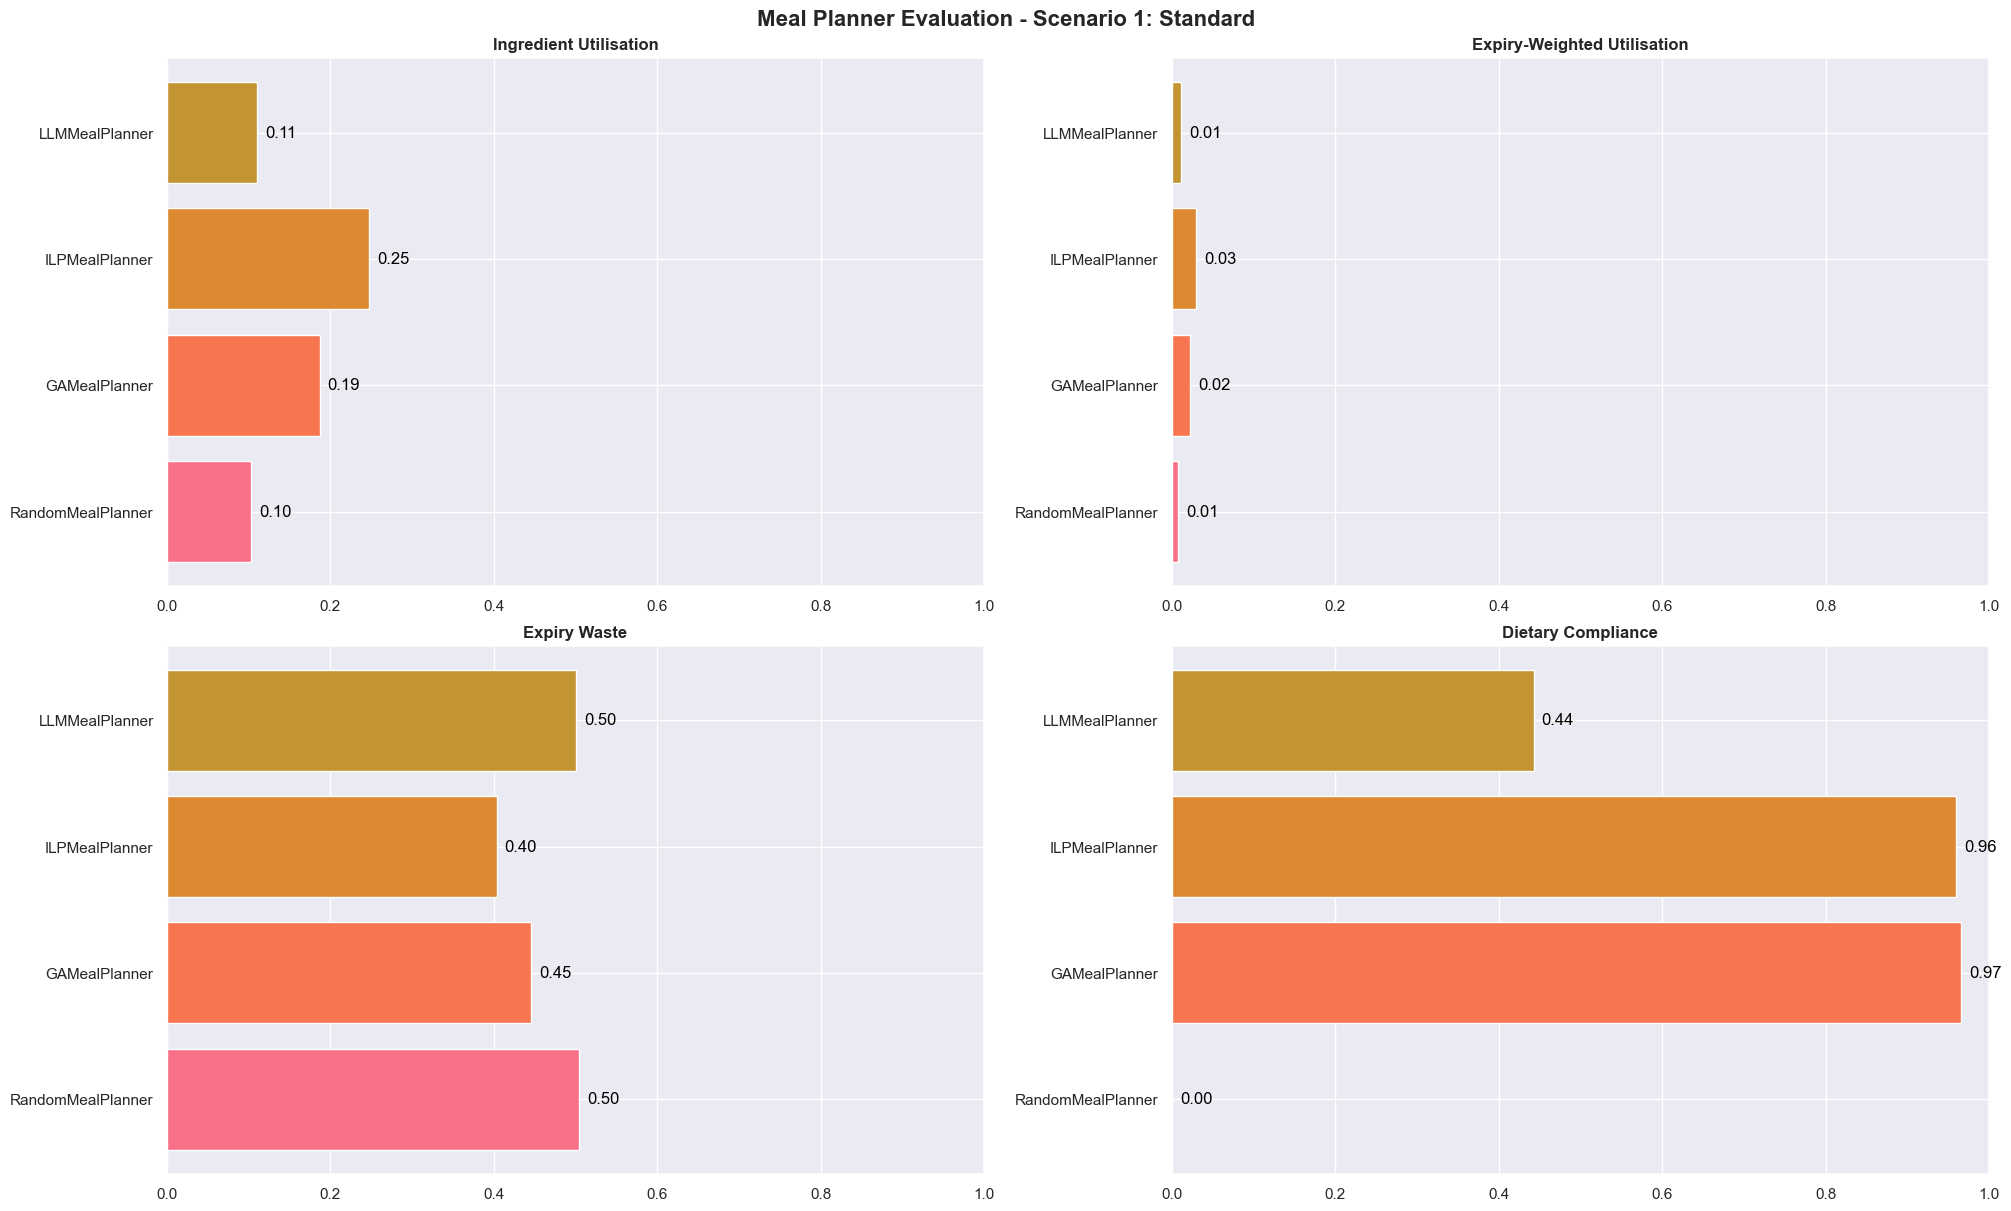

In [46]:
plot_metrics(scenario_1_metrics, f"Meal Planner Evaluation - {scenario_names[0]}")

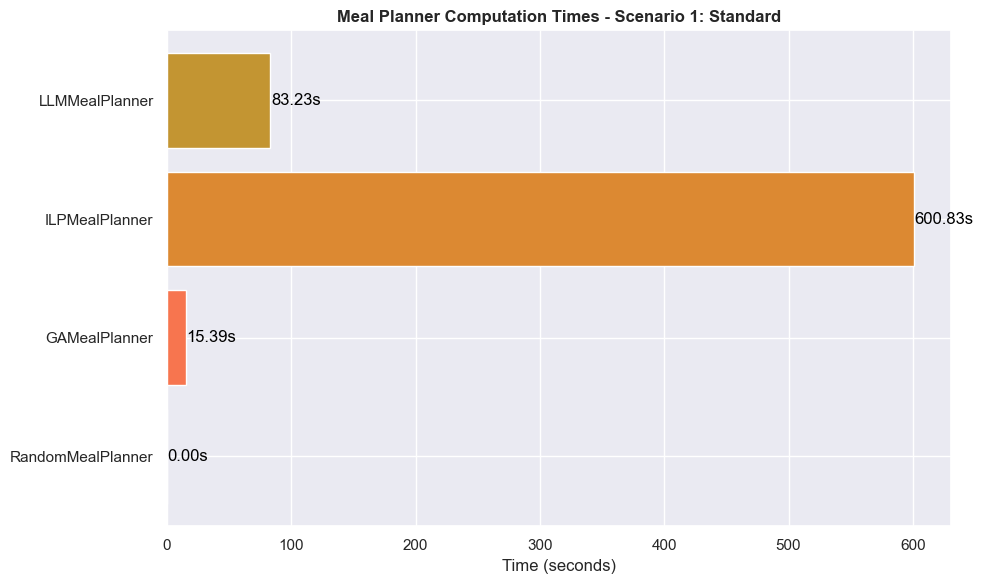

In [47]:
plot_computation_times(scenario_1_computation_times, f"Meal Planner Computation Times - {scenario_names[0]}")

### Scenario 2

In [48]:
scenario_2_metrics = {planner: metrics for (planner, scenario), metrics in planner_metrics.items() if scenario == 2}
scenario_2_computation_times = {
    planner: time for (planner, scenario), time in computation_times.items() if scenario == 2
}

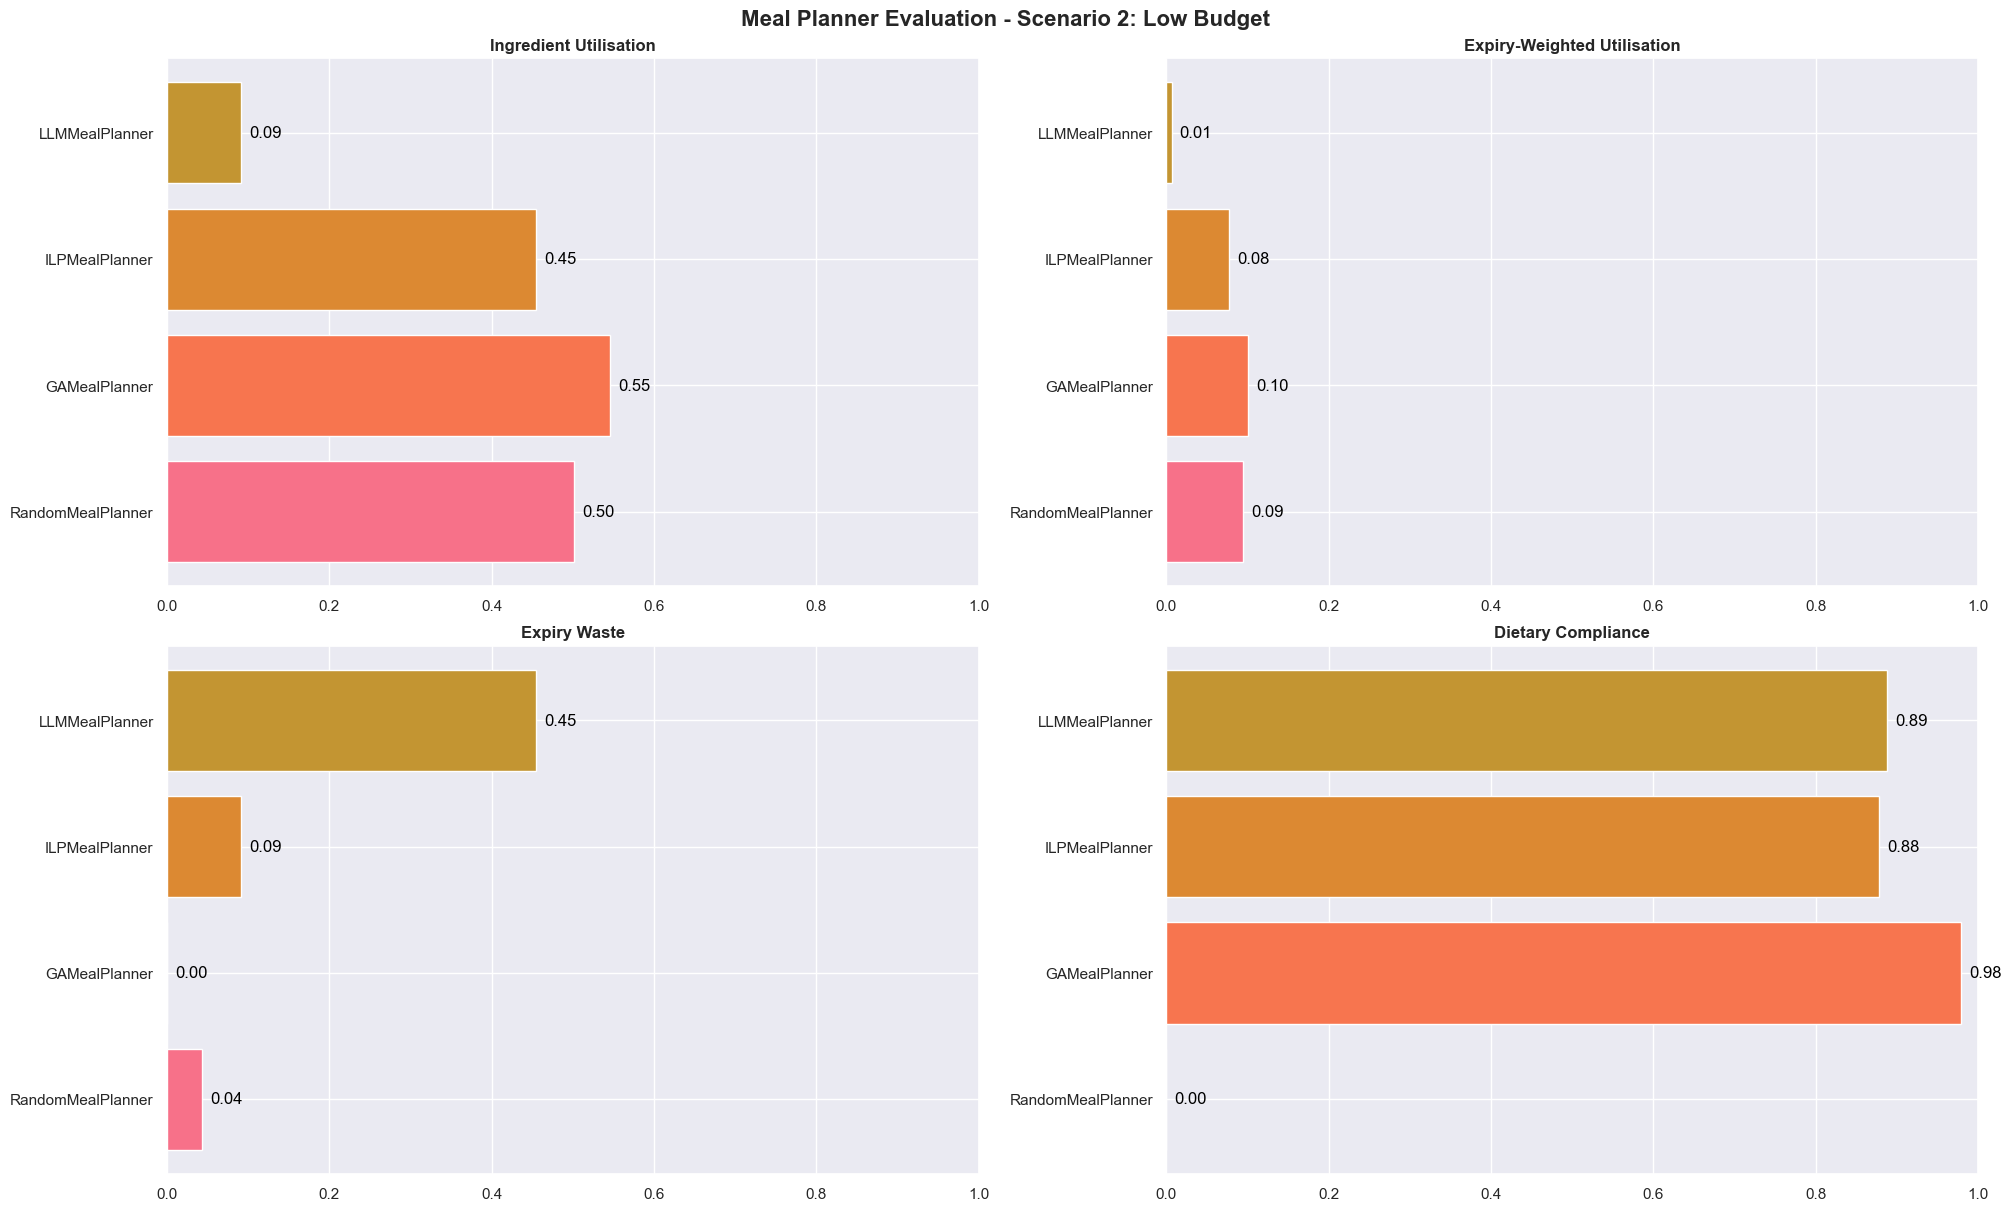

In [49]:
plot_metrics(scenario_2_metrics, f"Meal Planner Evaluation - {scenario_names[1]}")

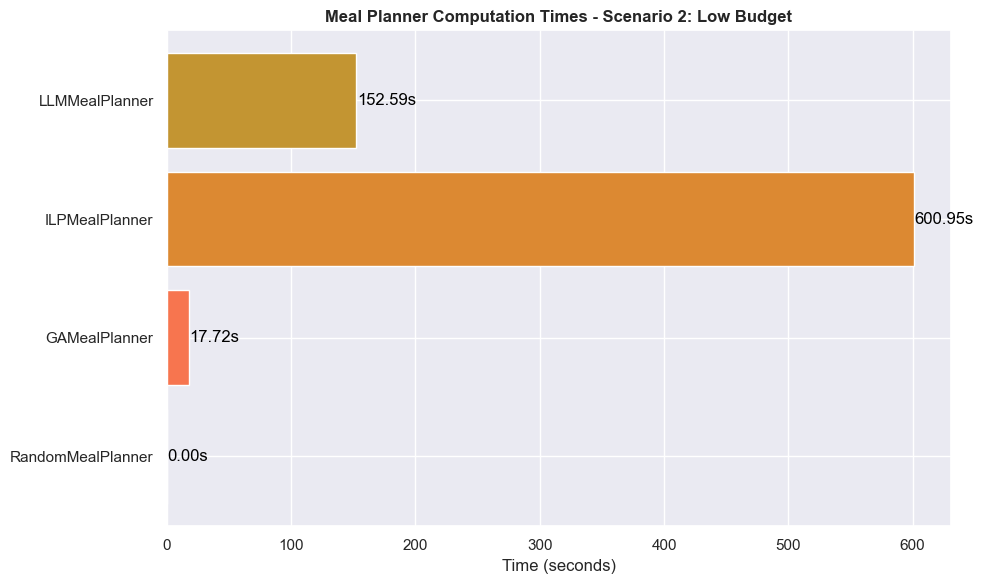

In [50]:
plot_computation_times(scenario_2_computation_times, f"Meal Planner Computation Times - {scenario_names[1]}")

### Scenario 3

In [51]:
scenario_3_metrics = {planner: metrics for (planner, scenario), metrics in planner_metrics.items() if scenario == 3}
scenario_3_computation_times = {
    planner: time for (planner, scenario), time in computation_times.items() if scenario == 3
}

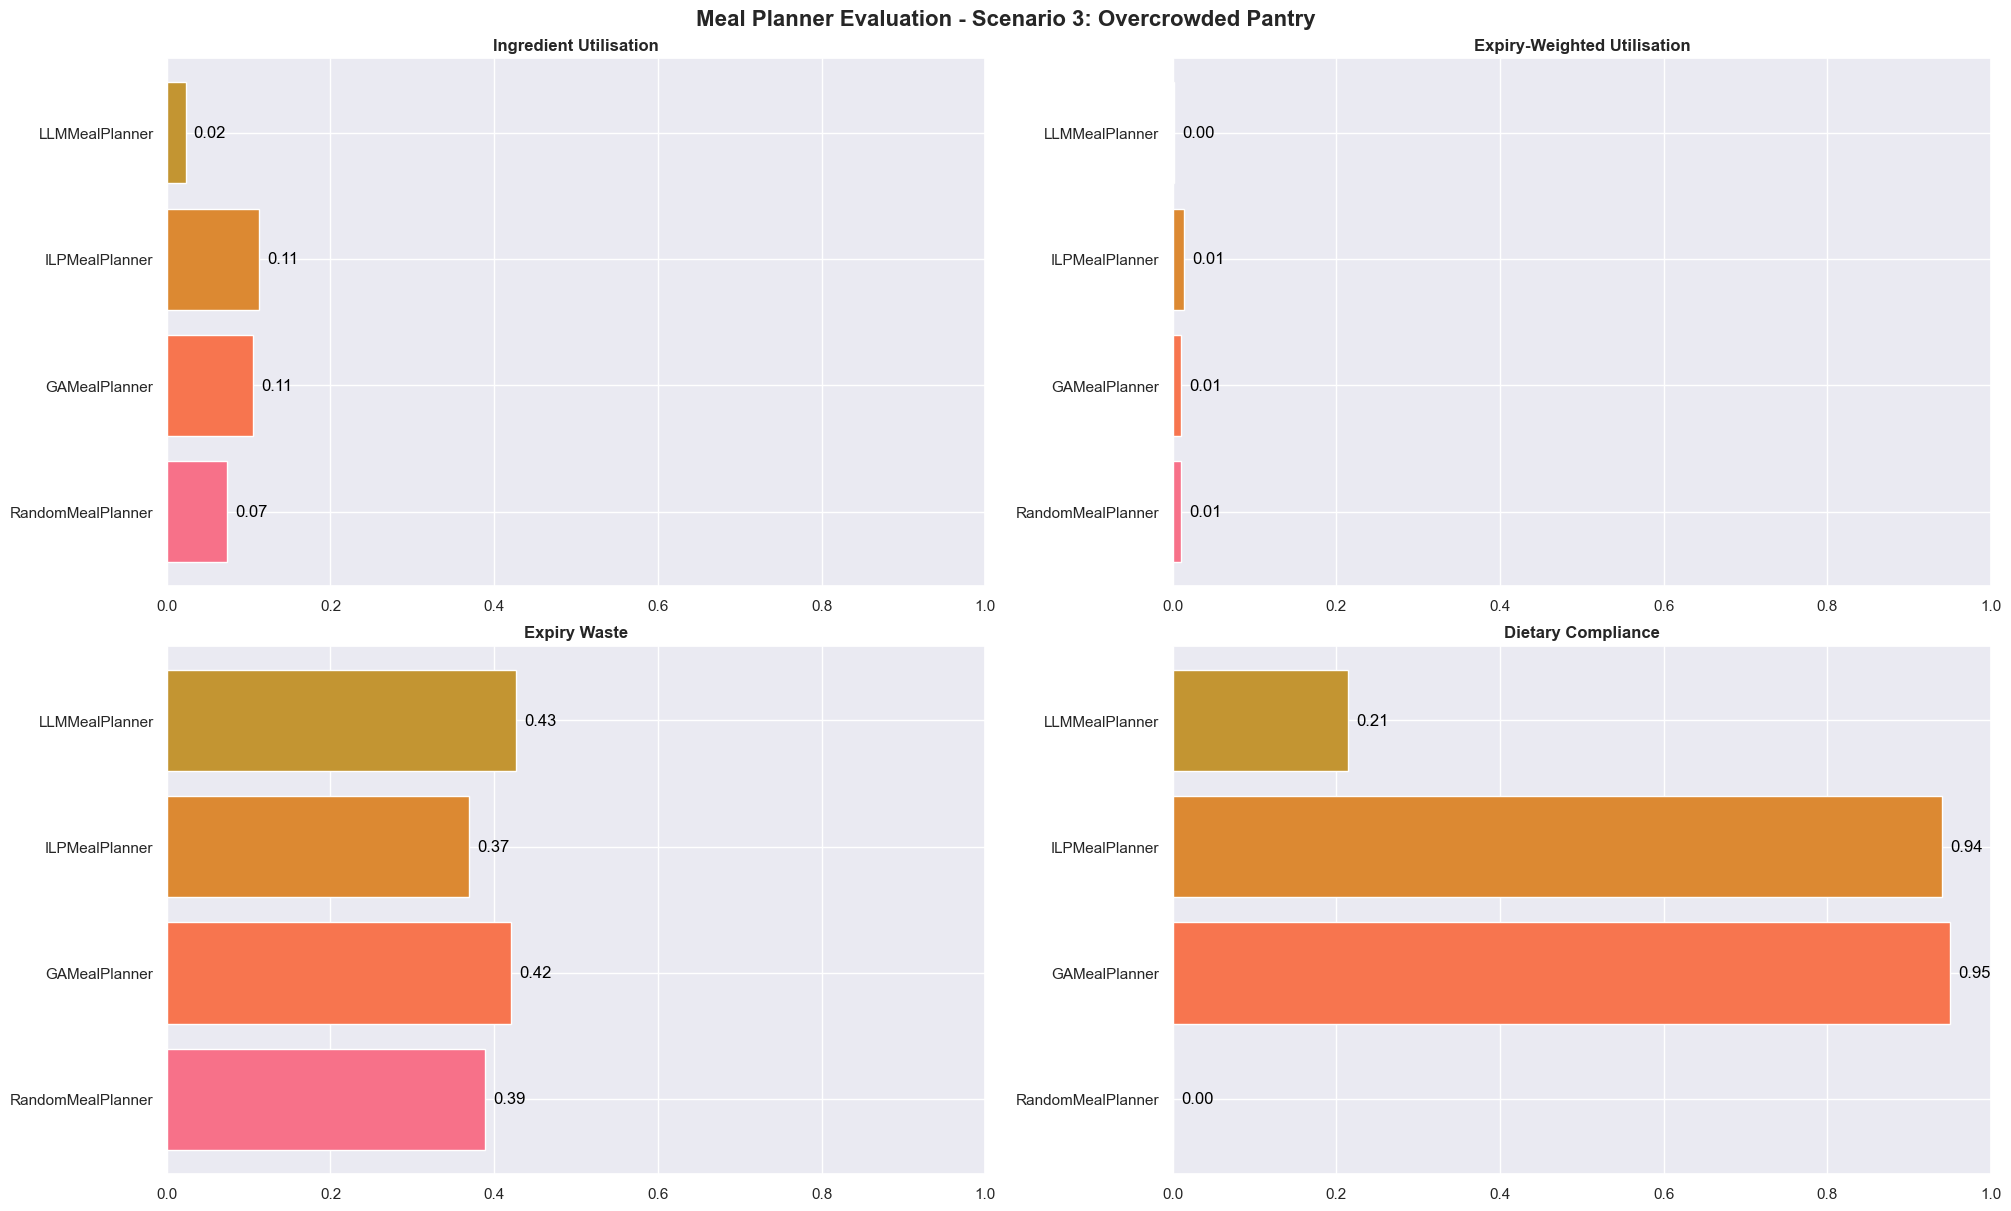

In [52]:
plot_metrics(scenario_3_metrics, f"Meal Planner Evaluation - {scenario_names[2]}")

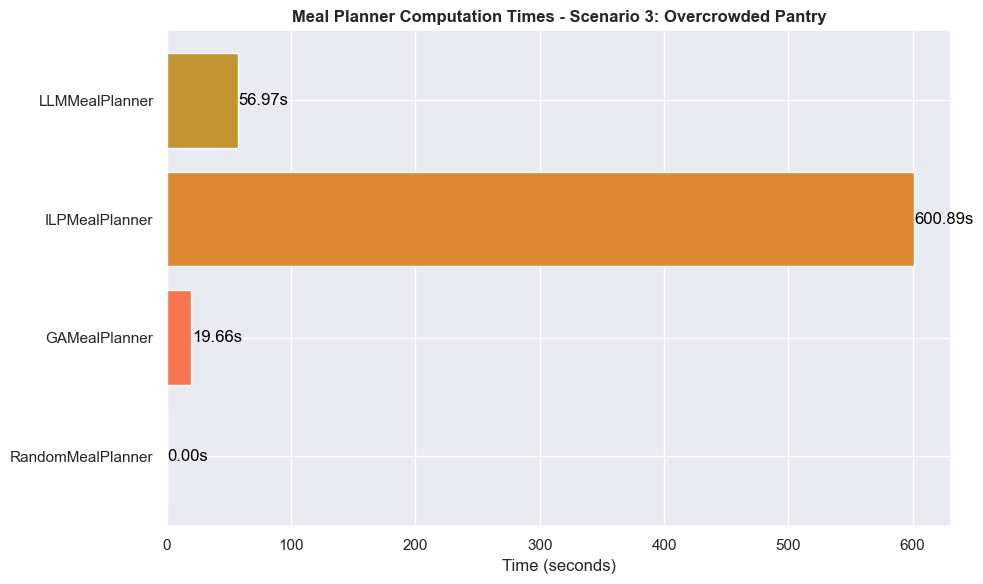

In [53]:
plot_computation_times(scenario_3_computation_times, f"Meal Planner Computation Times - {scenario_names[2]}")

### Scenario 4

In [54]:
scenario_4_metrics = {planner: metrics for (planner, scenario), metrics in planner_metrics.items() if scenario == 4}
scenario_4_computation_times = {
    planner: time for (planner, scenario), time in computation_times.items() if scenario == 4
}

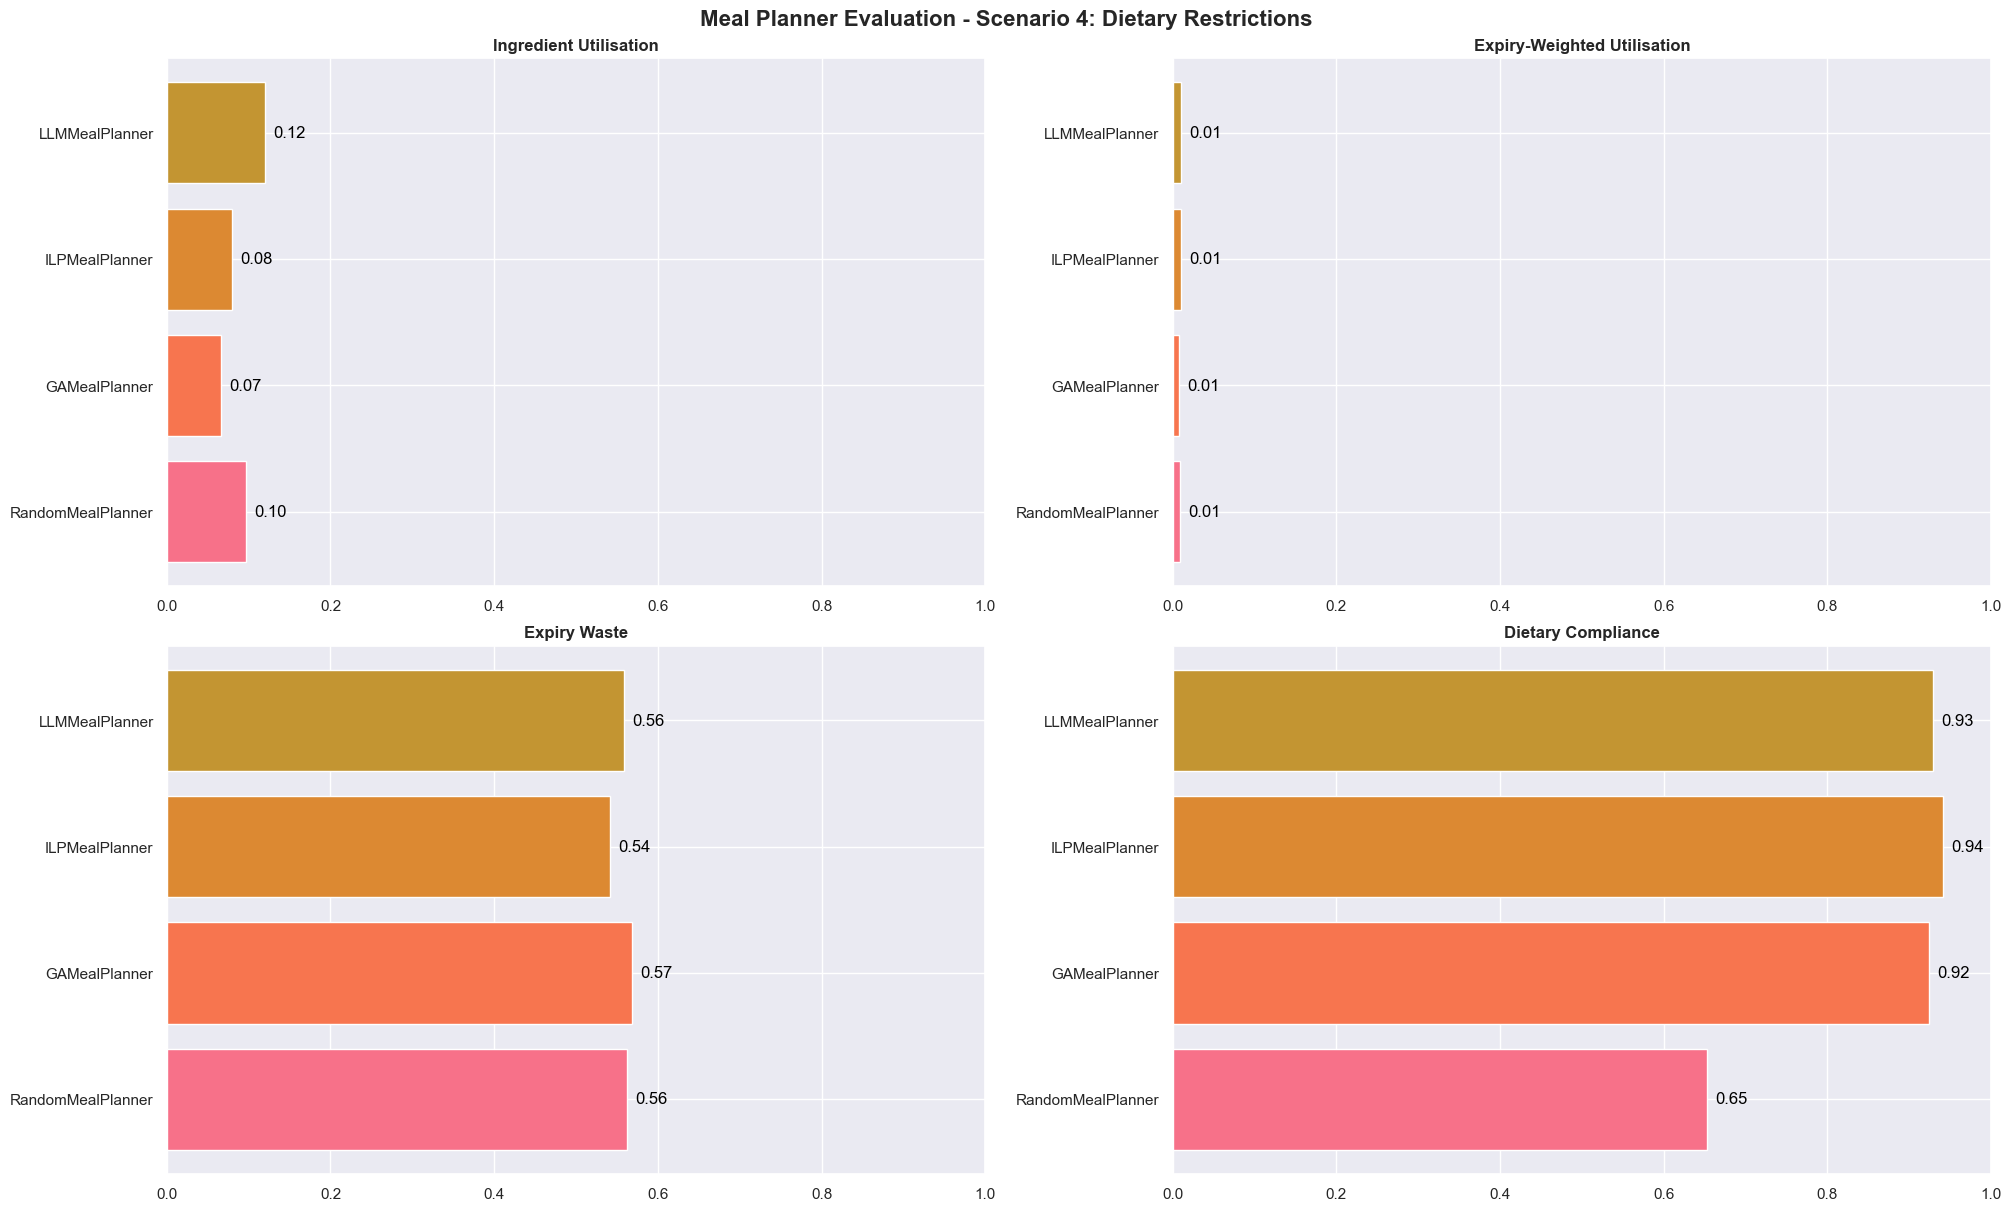

In [55]:
plot_metrics(scenario_4_metrics, f"Meal Planner Evaluation - {scenario_names[3]}")

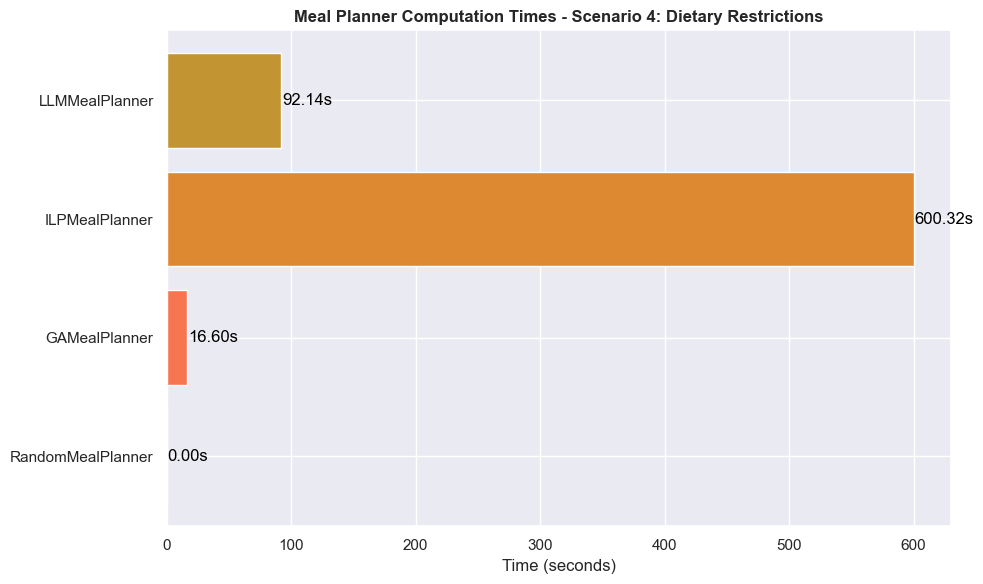

In [56]:
plot_computation_times(scenario_4_computation_times, f"Meal Planner Computation Times - {scenario_names[3]}")

### Scenario 5

In [57]:
scenario_5_metrics = {planner: metrics for (planner, scenario), metrics in planner_metrics.items() if scenario == 5}
scenario_5_computation_times = {
    planner: time for (planner, scenario), time in computation_times.items() if scenario == 5
}

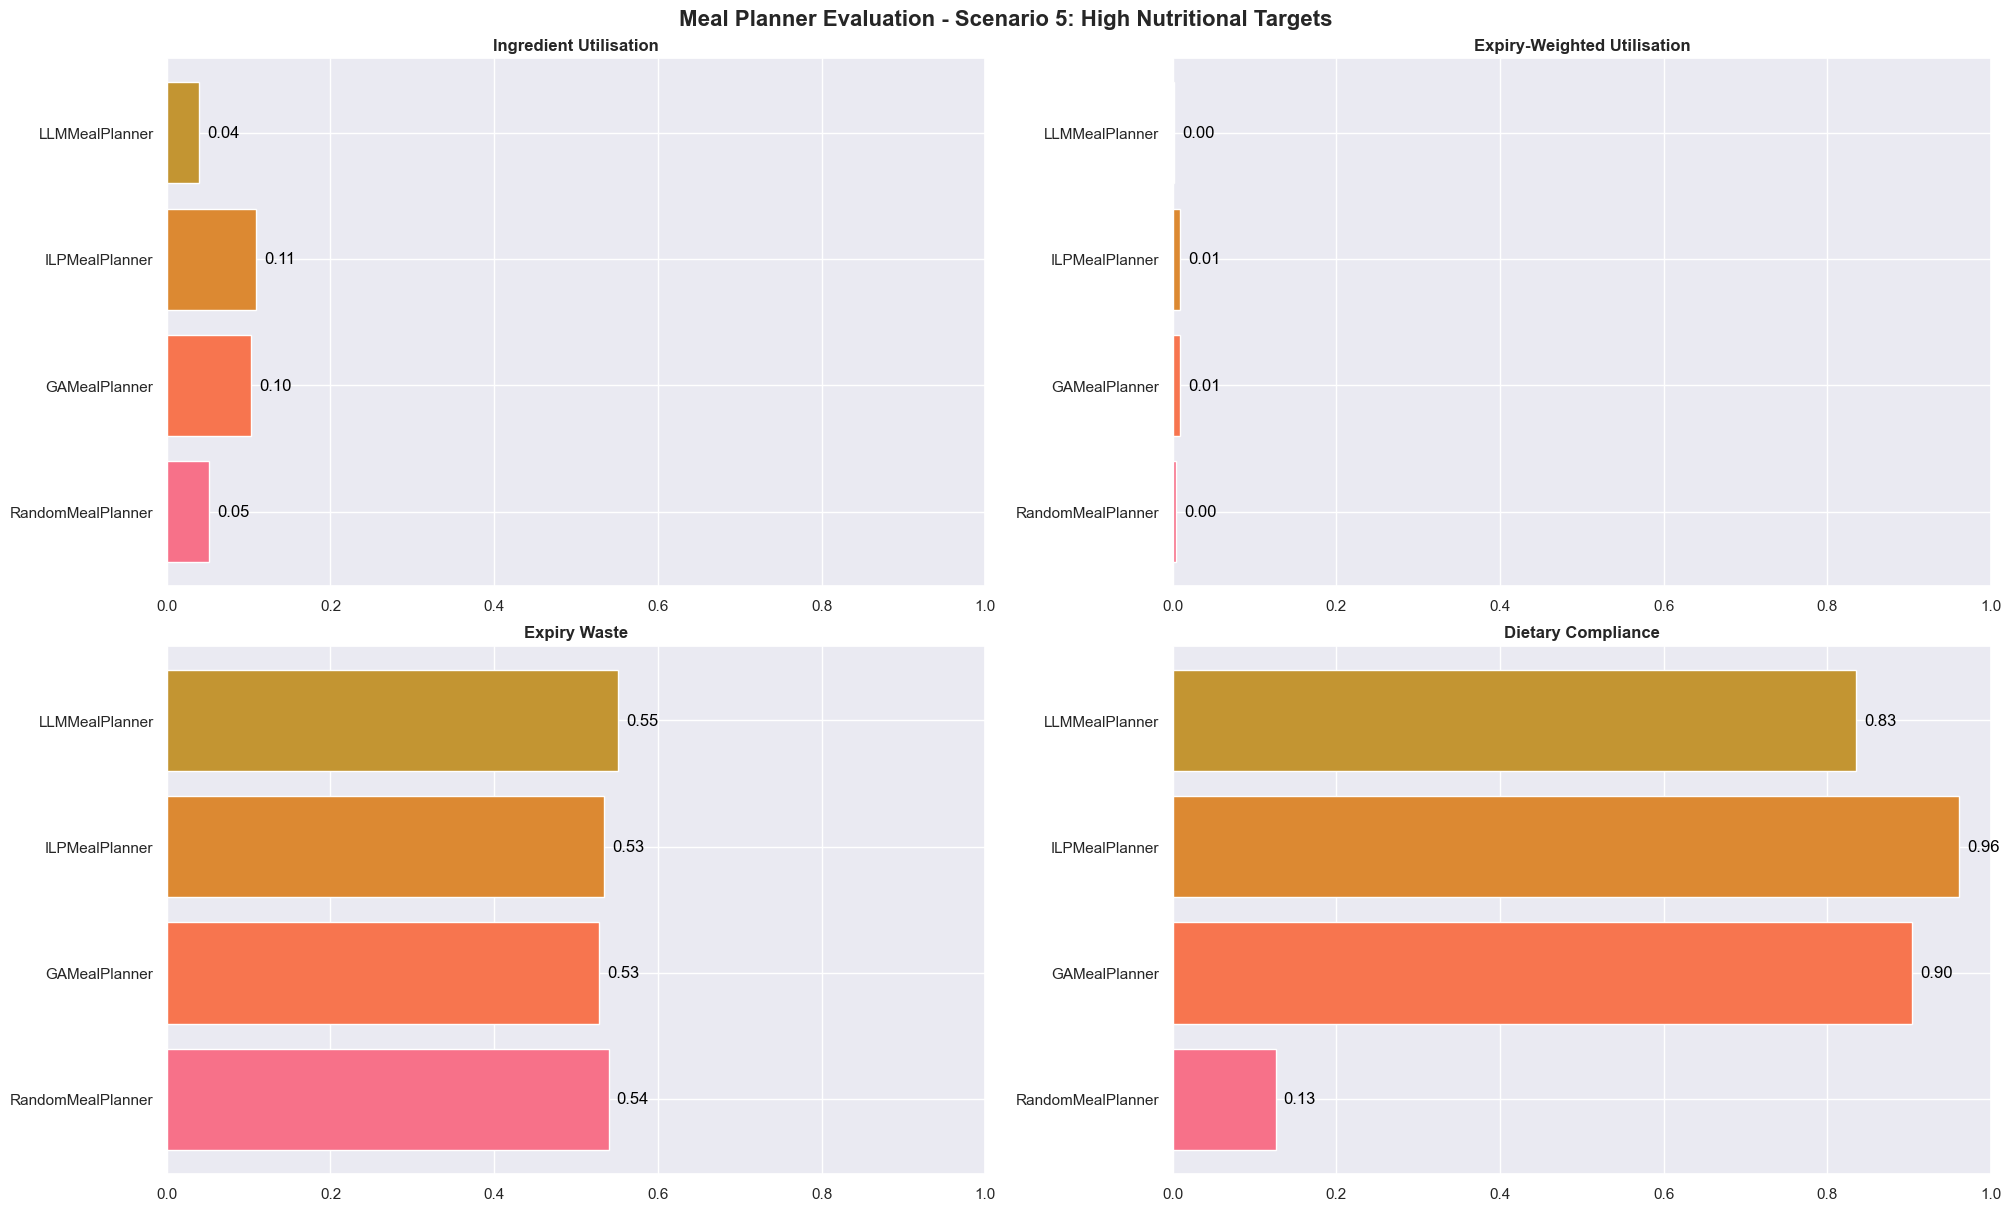

In [58]:
plot_metrics(scenario_5_metrics, f"Meal Planner Evaluation - {scenario_names[4]}")

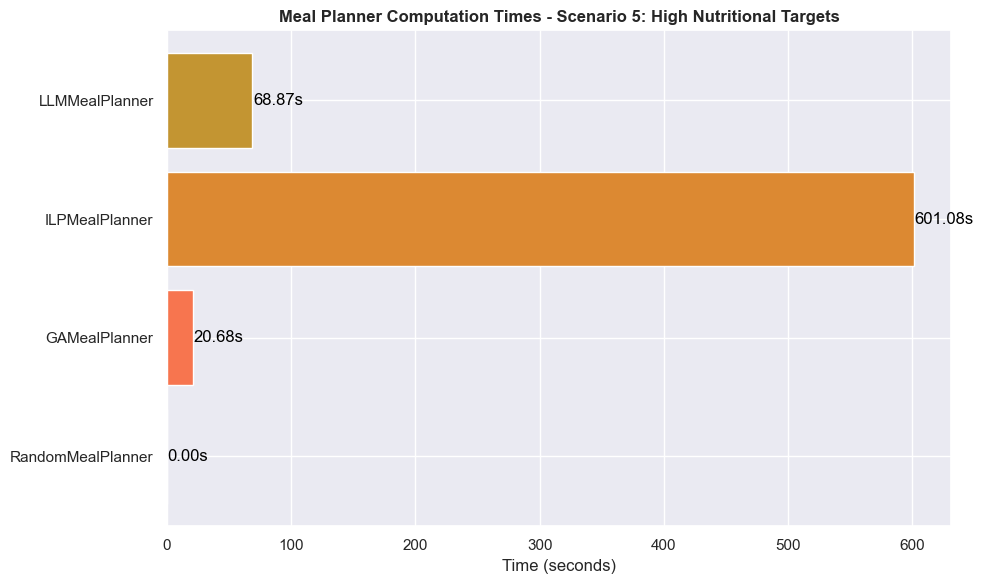

In [59]:
plot_computation_times(scenario_5_computation_times, f"Meal Planner Computation Times - {scenario_names[4]}")